# Particle steering: a worked solution

This notebook is the worked solution to the particle steering exercise in
tutorial 2. Attempt the exercise there first. The problem is stated in that
notebook, and repeated below so that this one stands on its own.

The **particle steering** problem is a minimum-time problem: steer a
constant-magnitude thrust vector so a particle reaches a given height with a
given terminal velocity as fast as possible. With position $(x_1, x_2)$,
velocity $(x_3, x_4)$, steering angle $u$ and acceleration magnitude
$a = 100$:

$$
\begin{aligned}
\min_{u,\, t_f}\quad & t_f \\
\text{s.t.}\quad & \dot x_1 = x_3, \qquad \dot x_2 = x_4, \\
& \dot x_3 = a \cos u, \qquad \dot x_4 = a \sin u, \\
& x(0) = 0, \qquad x_2(t_f) = 5,\ x_3(t_f) = 45,\ x_4(t_f) = 0, \\
& -\tfrac{\pi}{2} \le u(t) \le \tfrac{\pi}{2} .
\end{aligned}
$$

The final time is free, carried as an explicit `tf` variable that is also
the objective, and the states live in a 2-D matrix variable indexed like an
array.

> **Sources**
>
> Classical problem: A. E. Bryson and Y.-C. Ho, *Applied Optimal
> Control*, Wiley, 1975, pp. 59–62. The thrust magnitude and terminal
> conditions used here follow J. Betts, S. Eldersveld and W. Huffman,
> *Sparse nonlinear programming test problems (Release 1.0)*, Boeing
> Computer Services technical report BCSTECH-93-047, 1993, as collected
> in COPS 3.0 (problem 9): Dolan, Moré and Munson, ANL/MCS-TM-273, 2004.

In [1]:
using CUDA, CUDSS, ExaModels, MadNLP, MadNLPGPU
using Plots

## The model

One generator per family of dynamics constraints, exactly as in tutorial 2.
The `backend` argument is the only thing that decides CPU or GPU.

In [2]:
function steering_model(nh; backend = nothing)
    a = 100.0                                # thrust magnitude
    xs = zeros(4)                            # initial state: at rest at origin
    xf = [NaN, 5.0, 45.0, 0.0]               # target: y=5, ẋ=45, ẏ=0 (x free)
    x0(k, j) = j == 2 ? 5.0 * k / nh : j == 3 ? 45.0 * k / nh : 0.0

    core = ExaCore(; backend = backend)
    @add_var(core, u, 1:nh+1; lvar = -π/2, uvar = π/2, start = 0.0)
    @add_var(core, x, 1:nh+1, 1:4; start = [x0(i, j) for i = 1:nh+1, j = 1:4])
    @add_var(core, tf, 1; start = 1.0, lvar = 0.0)

    @add_obj(core, tf[1])  # minimize the final time

    # trapezoidal dynamics: positions integrate velocities,
    # velocities integrate the steered thrust
    @add_con(core, -x[i+1, 1] + x[i, 1] + tf[1]/2nh * (x[i, 3] + x[i+1, 3]) for i = 1:nh)
    @add_con(core, -x[i+1, 2] + x[i, 2] + tf[1]/2nh * (x[i, 4] + x[i+1, 4]) for i = 1:nh)
    @add_con(core, -x[i+1, 3] + x[i, 3] + tf[1]/2nh * (a*cos(u[i]) + a*cos(u[i+1])) for i = 1:nh)
    @add_con(core, -x[i+1, 4] + x[i, 4] + tf[1]/2nh * (a*sin(u[i]) + a*sin(u[i+1])) for i = 1:nh)

    # boundary conditions
    @add_con(core, -x[1, j] + s for (j, s) in enumerate(xs))
    @add_con(core, -x[nh+1, j] + f for (j, f) in zip(2:4, xf[2:4]))

    return ExaModel(core)
end

steering_model (generic function with 1 method)

## Solving it

On the GPU, at the tight tolerance tutorial 2 argued for. At the default
`tol = 1e-4` the condensed-space method would report a flight time slightly
below the true optimum, for the same reason it overshot Goddard's altitude.

In [3]:
steering = steering_model(2_000; backend = CUDABackend())
steering_result = madnlp(steering; max_iter = 600, tol = 1e-8)
(status = steering_result.status, flight_time = steering_result.objective,
 iterations = steering_result.iter)

This is MadNLP version v0.10.1, running with cuDSS v0.8.0

Number of nonzeros in constraint Jacobian............:    40007
Number of nonzeros in Lagrangian Hessian.............:    48000

Total number of variables............................:    10006
                     variables with only lower bounds:        1
                variables with lower and upper bounds:     2001
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:     8007
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:     8007
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du inf_compl lg(mu) lg(rg) alpha_pr ir ls
   0  1.0000000e+00 2.75e-02 0.00e+00 1.57e+00  -1.0     -   0.00e+00  0  0 
   1  9.9999950e-01 2.75e-02 2.15e-02 6.06e-04  -1.0     -   2.00e-07  2  2h
   2 

(status = MadNLP.SOLVE_SUCCEEDED, flight_time = 0.5545705674398755, iterations = 15)

The published optimum is 0.55457. COPS reports 0.554577 at `nh` = 200 and
0.554571 at `nh` = 800, so the discretized optimum itself shifts slightly as
the mesh is refined, and a value near 0.5546 at `nh` = 2000 is the expected
answer rather than a discrepancy.

## The steering angle

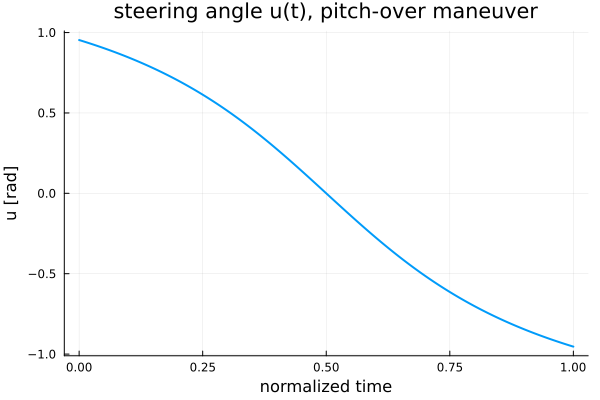

In [4]:
u_steer = Array(solution(steering_result, steering.refs.u))
plot(range(0, 1; length = length(u_steer)), u_steer;
    legend = false, lw = 2, title = "steering angle u(t), pitch-over maneuver",
    xlabel = "normalized time", ylabel = "u [rad]")

The angle starts positive, so the thrust is directed upward to gain height,
and decreases monotonically through zero to a negative value. The particle
pitches over and thrusts increasingly downrange to build the horizontal
velocity the terminal condition demands, while the vertical velocity is
brought back to zero at exactly the target height. The profile is smooth
here, with no bang-bang or singular structure, because the control enters
the dynamics through $\cos u$ and $\sin u$ rather than linearly.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*